In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Set style for better plots
plt.style.use("default")
sns.set_palette("tab10")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12

In [41]:
# Define paths
results_dir = Path("../results/intrinsic_dimension")

# Algorithm directories
algorithms = ["MLE", "twoNN", "scaling_gride"]

print("Available algorithms:", algorithms)
for algo in algorithms:
    algo_dir = results_dir / algo
    if algo_dir.exists():
        files = list(algo_dir.glob("*.csv"))
        print(f"{algo}: {len(files)} files")
    else:
        print(f"{algo}: Directory not found")

Available algorithms: ['MLE', 'twoNN', 'scaling_gride']
MLE: 10 files
twoNN: 10 files
scaling_gride: 10 files


In [42]:
def parse_filename(filename):
    """Parse filename to extract model, dataset, and modality information."""
    # Remove .csv extension
    name = filename.stem

    # Extract model name
    if "llava-hf_llava-1.5-7b-hf" in name:
        model = "LLaVA 1.5 7B"
    elif "lmsys_vicuna-7b-v1.5" in name:
        model = "Vicuna 1.5 7B"
    else:
        model = "Unknown"

    # Extract dataset
    if "scienceqa" in name:
        dataset = "SQA"
    elif "mmlu" in name:
        dataset = "MMLU"
    elif "cocoqa_unified" in name:
        dataset = "COCOQA"
    else:
        dataset = "Unknown"

    # Extract modality
    if "img-qa" in name:
        modality = "IMG"
    elif "txt-qa" in name:
        modality = "TXT"
    else:
        modality = ""

    return model, dataset, modality


def load_all_data():
    """Load all CSV files and combine into a single DataFrame."""
    all_data = []

    for algo in algorithms:
        algo_dir = results_dir / algo
        if not algo_dir.exists():
            continue

        for csv_file in algo_dir.glob("*.csv"):
            try:
                df = pd.read_csv(csv_file)
                model, dataset, modality = parse_filename(csv_file)

                # Add metadata columns
                df["algorithm"] = algo
                df["model"] = model
                df["dataset"] = dataset
                df["modality"] = modality
                df["filename"] = csv_file.name

                all_data.append(df)

            except Exception as e:
                print(f"Error loading {csv_file}: {e}")

    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()


# Load all data
data = load_all_data()
print(f"Loaded {len(data)} total data points")
print("\nData summary:")
print(data.groupby(["algorithm", "model", "dataset", "modality"]).size())

Loaded 960 total data points

Data summary:
algorithm      model          dataset  modality
MLE            LLaVA 1.5 7B   COCOQA   IMG         32
                                       TXT         32
                              MMLU     TXT         32
                              SQA      IMG         32
                                       TXT         32
               Vicuna 1.5 7B  COCOQA   IMG         32
                                       TXT         32
                              MMLU     TXT         32
                              SQA      IMG         32
                                       TXT         32
scaling_gride  LLaVA 1.5 7B   COCOQA   IMG         32
                                       TXT         32
                              MMLU     TXT         32
                              SQA      IMG         32
                                       TXT         32
               Vicuna 1.5 7B  COCOQA   IMG         32
                                       TXT  

In [43]:
# Display first few rows to understand the data structure
print("Sample data:")
print(data.head())
print("\nColumn names:")
print(data.columns.tolist())

Sample data:
   layer_index  intrinsic_dimension algorithm         model dataset modality  \
0            1            13.551616       MLE  LLaVA 1.5 7B  COCOQA      IMG   
1            2            16.907404       MLE  LLaVA 1.5 7B  COCOQA      IMG   
2            3            17.538378       MLE  LLaVA 1.5 7B  COCOQA      IMG   
3            4            18.189959       MLE  LLaVA 1.5 7B  COCOQA      IMG   
4            5            16.970409       MLE  LLaVA 1.5 7B  COCOQA      IMG   

                                            filename  
0  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  
1  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  
2  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  
3  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  
4  llava-hf_llava-1.5-7b-hf_cocoqa_captioning_res...  

Column names:
['layer_index', 'intrinsic_dimension', 'algorithm', 'model', 'dataset', 'modality', 'filename']


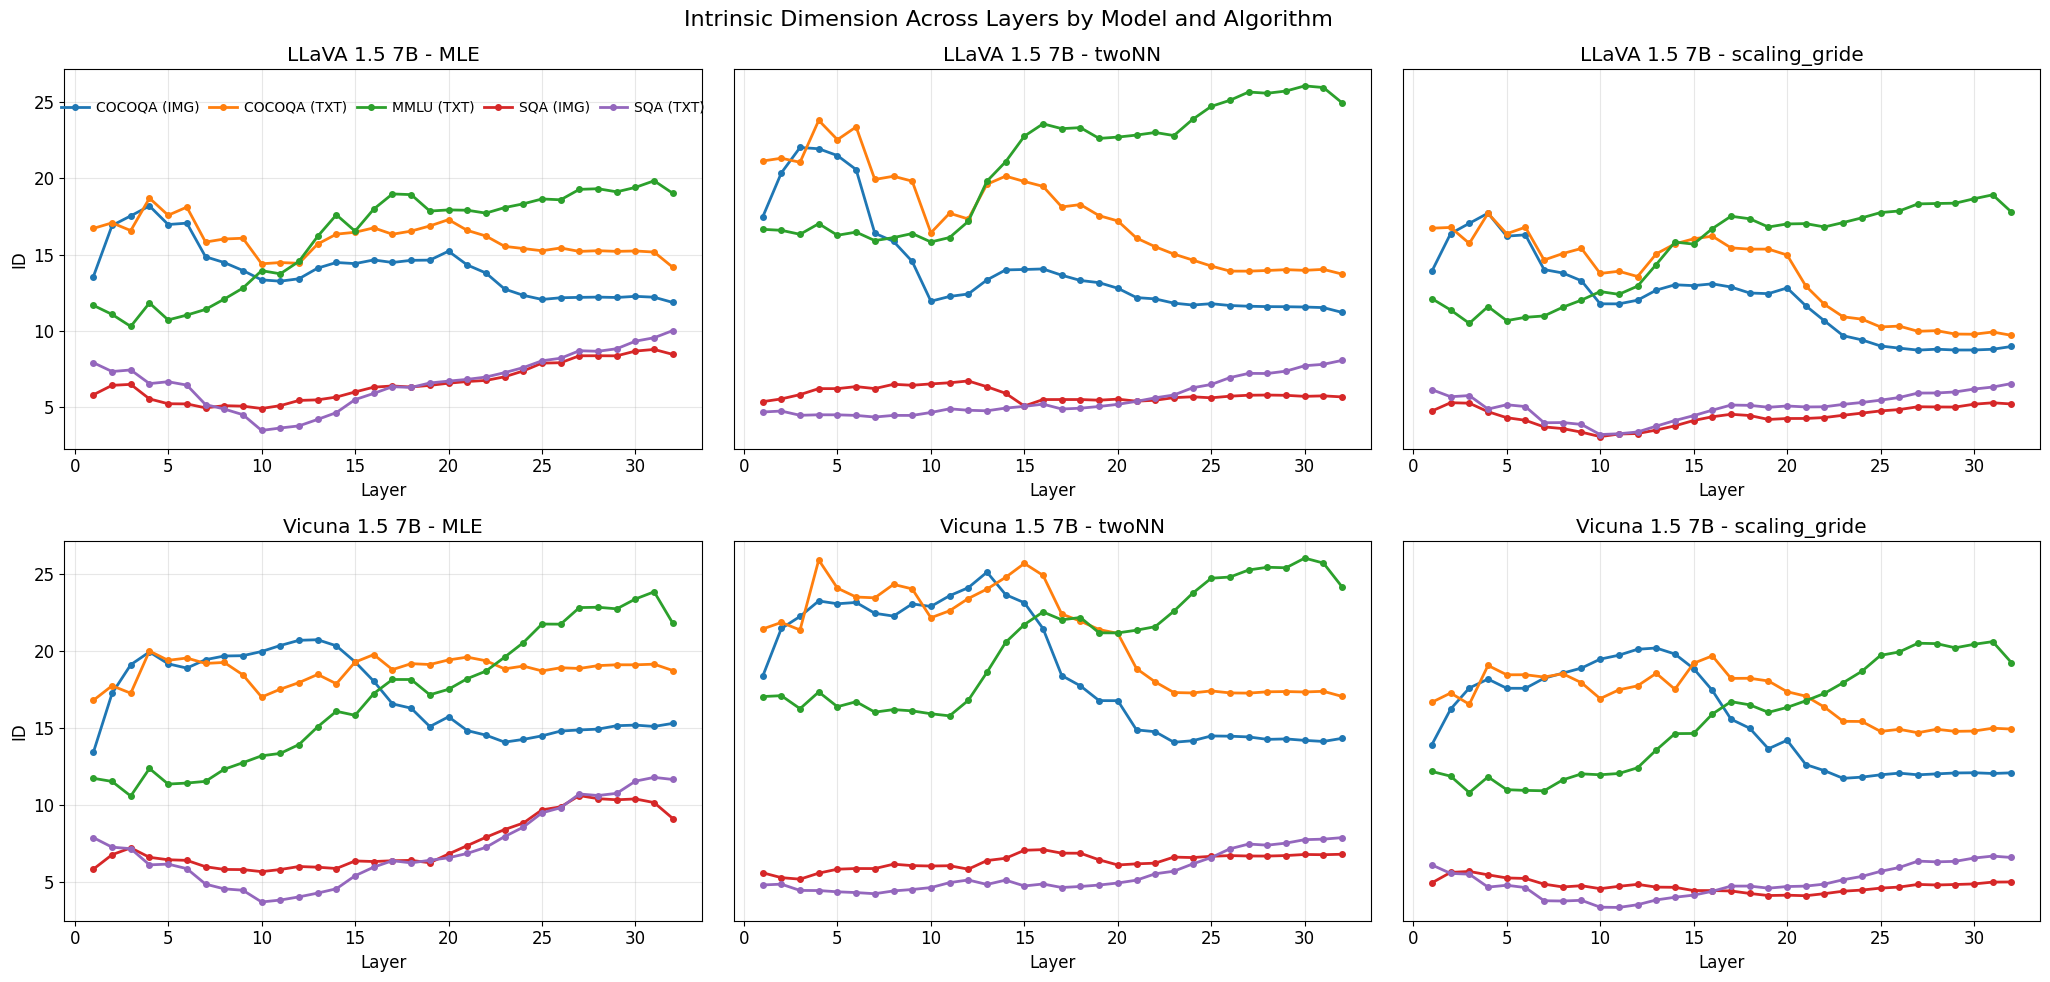

In [45]:
def plot_intrinsic_dimension_by_model():
    """Plot intrinsic dimension across layers for each model separately."""

    models = data["model"].unique()
    algorithms = data["algorithm"].unique()
    
    num_rows = len(models)
    num_cols = len(algorithms)
    
    fig, axes = plt.subplots(num_rows, num_cols,
                             figsize=(7*num_cols, 5*num_rows), # width, height
                             )
    fig.suptitle(
        "Intrinsic Dimension Across Layers by Model and Algorithm", fontsize=16, y=0.98
    )
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))  # Get distinct colors
    color_map = {}
    
    legend_handles = []
    legend_labels = []

    for row, model in enumerate(models):
        for col, algo in enumerate(algorithms):
            ax = axes[row, col]

            # Filter data for this model and algorithm
            model_algo_data = data[
                (data["model"] == model) & (data["algorithm"] == algo)
            ]

            if len(model_algo_data) == 0:
                ax.set_title(f"{model} - {algo}\n(No data)")
                continue
            
            # Plot each dataset-modality combination
            color_idx = 0
            for (dataset, modality), group in model_algo_data.groupby(['dataset', 'modality']):
                label = f'{dataset} ({modality})'
                
                # Assign consistent colors
                if label not in color_map:
                    color_map[label] = colors[color_idx % len(colors)]
                    color_idx += 1
                
                line = ax.plot(group['layer_index'], group['intrinsic_dimension'], 
                              marker='o', linewidth=2, markersize=4, 
                              label=label, color=color_map[label])
                
                # Store legend info only from first plot
                if row == 0 and col == 0 and label not in legend_labels:
                    legend_handles.append(line[0])
                    legend_labels.append(label)

            ax.set_title(f"{model} - {algo}")
            ax.set_xlabel("Layer")
            ax.set_ylabel("ID")
            ax.grid(True, alpha=0.3)
            
            # Add extra space at the top for the first plot only
            if row == 0 and col == 0:
                # Get current y limits and extend upper limit
                y_min, y_max = ax.get_ylim()
                y_range = y_max - y_min
                ax.set_ylim(y_min, y_max + 0.3 * y_range)  # Add 30% more space at top
                
                # Add horizontal legend inside the plot
                ax.legend(legend_handles, legend_labels, 
                         loc='upper center', bbox_to_anchor=(0.5, 0.95),
                         ncol=len(legend_labels), fontsize=10, frameon=False, 
                         fancybox=False, shadow=False, 
                         handletextpad=0.5,                 # space between marker and text
                         columnspacing=0.7,                 # space between columns (i.e., legend entries)
                         labelspacing=0.5,                 # space between legend entries
                         )
                
    # Link Y axes per model (per row)
    for row in range(len(models)):
        y_mins = []
        y_maxs = []
        for col in range(len(algorithms)):
            ax = axes[row, col]
            y_min, y_max = ax.get_ylim()
            y_mins.append(y_min)
            y_maxs.append(y_max)
            if col > 0:
                # delete y label and ticks
                ax.set_ylabel('')
                ax.set_yticks([])
        
        # Set all axes in the row to the same y-limits
        y_min_row = min(y_mins)
        y_max_row = max(y_maxs)
        for col in range(len(algorithms)):
            axes[row, col].set_ylim(y_min_row, y_max_row)

                

    plt.tight_layout()
    fig.subplots_adjust(wspace=0.05)  # reduce horizontal space between columns
    # plt.savefig(plots_dir / 'intrinsic_dimension_by_model_algorithm.png', dpi=300, bbox_inches='tight')
    plt.show()


plot_intrinsic_dimension_by_model()
